In [ ]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

font_path = "/content/Times New Normal Regular.ttf"

fm.fontManager.addfont(font_path)

prop = fm.FontProperties(fname=font_path)

mpl.rcParams['font.family'] = prop.get_name()

plt.rcParams['font.family'] = prop.get_name()

In [ ]:
!pip install gprofiler-official

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from gprofiler import GProfiler
import ast

/tmp/ipykernel_24918/3227077132.py:159: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times New Normal.
  plt.tight_layout()
/tmp/ipykernel_24918/3227077132.py:159: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_24918/3227077132.py:163: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_24918/3227077132.py:164: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times New Normal.
  plt.savefig("GO_BP_BICC1.svg", format="svg", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times New Normal.
  fig.canvas.print_figure(bytes_io, **kw)


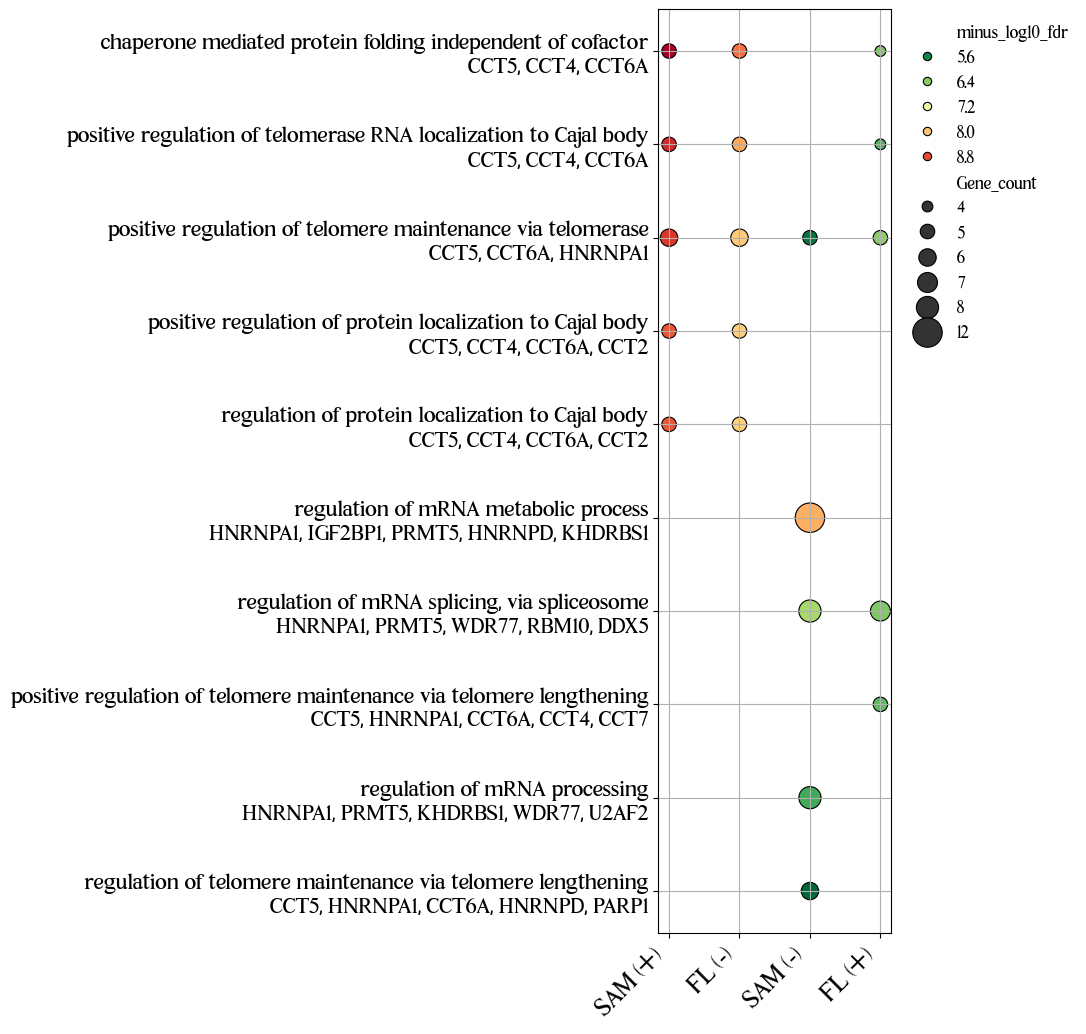

In [ ]:
def format_genes(gene_list):

    if isinstance(gene_list, str):

        try:
            genes = ast.literal_eval(gene_list)
        except:
            genes = gene_list.replace("[","").replace("]","").replace("'","").split(",")

    else:
        genes = list(gene_list)

    genes = [str(g).strip() for g in genes if str(g).strip() != ""]
    genes = list(dict.fromkeys(genes))

    if len(genes) > 5:
        return ", ".join(genes[:5]) + ", ..."
    else:
        return ", ".join(genes)

def build_common_gene_labels(plot_df, max_genes=5):

    def parse_gene_set(x):

        if isinstance(x, str):
            try:
                genes = ast.literal_eval(x)
            except:
                genes = x.replace("[","").replace("]","").replace("'","").split(",")
        else:
            genes = list(x)

        return set([str(g).strip() for g in genes if str(g).strip() != ""])

    label_map = {}

    for go_term, sub in plot_df.groupby("GO_term"):

        gene_sets = [parse_gene_set(x) for x in sub["intersections"]]

        if len(gene_sets) > 1:
            common = set.intersection(*gene_sets)
        else:
            common = gene_sets[0]

        common = list(common)

        if len(common) == 0:
            label = format_genes(sub["intersections"].iloc[0])
        else:
            label = ", ".join(common[:max_genes])

        label_map[go_term] = label

    plot_df["Gene_label_common"] = plot_df["GO_term"].map(label_map)

    return plot_df

df = pd.read_excel("GO_BICC1.xlsx")

gp = GProfiler(return_dataframe=True)

go_results = []

for condition in df.columns:

    genes = df[condition].dropna().astype(str).unique().tolist()

    if len(genes) == 0:
        continue

    res = gp.profile(
        organism="hsapiens",
        query=genes,
        sources=["GO:BP"],
        no_evidences=False
    )

    if res is not None and not res.empty:
        res["Condition"] = condition
        go_results.append(res)

if len(go_results) == 0:
    raise ValueError("Nenhum enrichment encontrado")

go_df = pd.concat(go_results, ignore_index=True)

go_df = go_df[go_df["significant"] == True].copy()

go_df["minus_log10_fdr"] = -np.log10(go_df["p_value"])

top_terms = (
    go_df
    .sort_values("p_value")
    .groupby("Condition")
    .head(5)
)

plot_df = top_terms.rename(columns={
    "name": "GO_term",
    "intersection_size": "Gene_count"
})

plot_df = build_common_gene_labels(plot_df)

plot_df["GO_label"] = (
    plot_df["GO_term"] + "\n" + plot_df["Gene_label_common"]
)
term_order = plot_df["GO_label"].drop_duplicates().tolist()

plot_df["GO_label"] = pd.Categorical(
    plot_df["GO_label"],
    categories=term_order,
    ordered=True
)

plt.figure(figsize=(3, 12))

ax = sns.scatterplot(
    data=plot_df,
    x="Condition",
    y="GO_label",
    size="Gene_count",
    hue="minus_log10_fdr",
    palette="RdYlGn_r",
    sizes=(60, 450),
    edgecolor="black"
)

plt.xticks(rotation=45, ha="right", fontsize=18)
plt.yticks(fontsize=16)

plt.xlabel("")
plt.ylabel("")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=12,
    title_fontsize=12
)

plt.tight_layout()
plt.grid()


plt.tight_layout()
plt.savefig("GO_BP_BICC1.svg", format="svg", bbox_inches="tight")
plt.show()

/tmp/ipykernel_24918/3859114166.py:151: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times New Normal.
  plt.tight_layout()
/tmp/ipykernel_24918/3859114166.py:151: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_24918/3859114166.py:154: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()
/tmp/ipykernel_24918/3859114166.py:155: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times New Normal.
  plt.savefig("GO_CC_BICC1.svg", format="svg", bbox_inches="tight")
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 916 (\N{GREEK CAPITAL LETTER DELTA}) missing from font(s) Times New Normal.
  fig.canvas.print_figure(bytes_io, **kw)


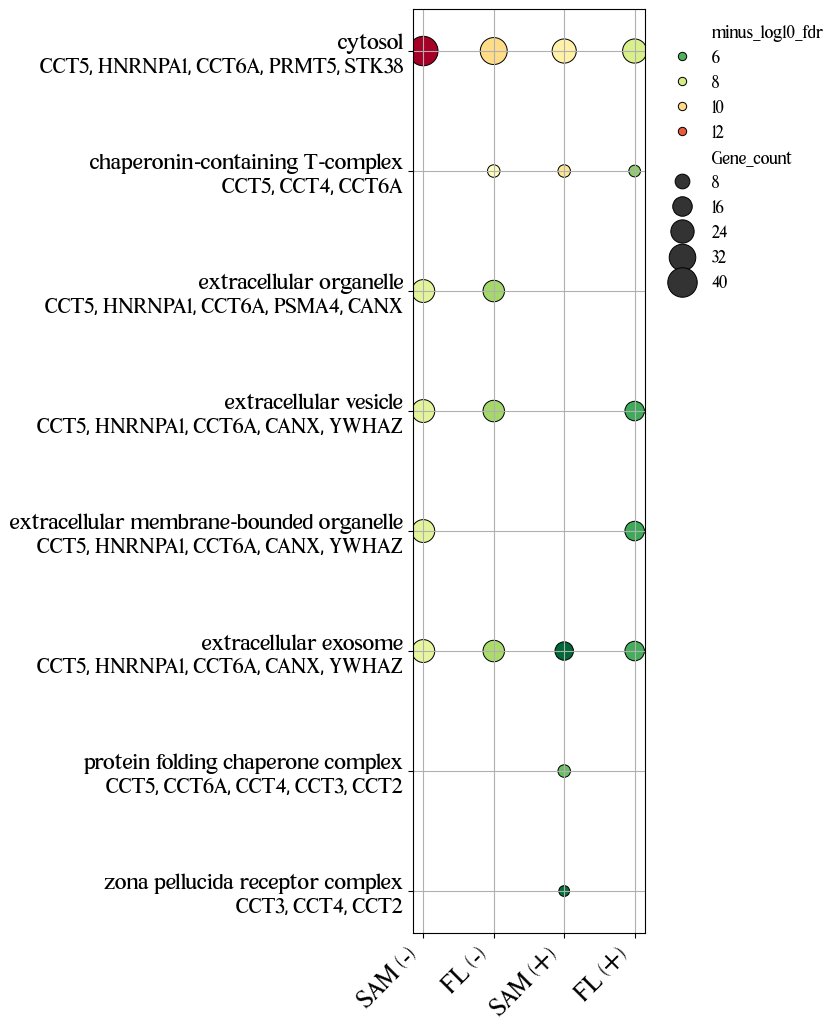

In [ ]:
def format_genes(gene_list):

    if isinstance(gene_list, str):

        try:
            genes = ast.literal_eval(gene_list)
        except:
            genes = gene_list.replace("[","").replace("]","").replace("'","").split(",")

    else:
        genes = list(gene_list)

    genes = [str(g).strip() for g in genes if str(g).strip() != ""]
    genes = list(dict.fromkeys(genes))

    if len(genes) > 5:
        return ", ".join(genes[:5]) + ", ..."
    else:
        return ", ".join(genes)

def build_common_gene_labels(plot_df, max_genes=5):

    def parse_gene_set(x):

        if isinstance(x, str):
            try:
                genes = ast.literal_eval(x)
            except:
                genes = x.replace("[","").replace("]","").replace("'","").split(",")
        else:
            genes = list(x)

        return set([str(g).strip() for g in genes if str(g).strip() != ""])

    label_map = {}

    for go_term, sub in plot_df.groupby("GO_term"):

        gene_sets = [parse_gene_set(x) for x in sub["intersections"]]

        if len(gene_sets) > 1:
            common = set.intersection(*gene_sets)
        else:
            common = gene_sets[0]

        common = list(common)

        if len(common) == 0:
            label = format_genes(sub["intersections"].iloc[0])
        else:
            label = ", ".join(common[:max_genes])

        label_map[go_term] = label

    plot_df["Gene_label_common"] = plot_df["GO_term"].map(label_map)

    return plot_df

df = pd.read_excel("GO_BICC1.xlsx")

gp = GProfiler(return_dataframe=True)

go_results = []

for condition in df.columns:

    genes = df[condition].dropna().astype(str).unique().tolist()

    if len(genes) == 0:
        continue

    res = gp.profile(
        organism="hsapiens",
        query=genes,
        sources=["GO:CC"],
        no_evidences=False
    )

    if res is not None and not res.empty:
        res["Condition"] = condition
        go_results.append(res)

if len(go_results) == 0:
    raise ValueError("Nenhum enrichment encontrado")

go_df = pd.concat(go_results, ignore_index=True)

go_df = go_df[go_df["significant"] == True].copy()

go_df["minus_log10_fdr"] = -np.log10(go_df["p_value"])

top_terms = (
    go_df
    .sort_values("p_value")
    .groupby("Condition")
    .head(5)
)

plot_df = top_terms.rename(columns={
    "name": "GO_term",
    "intersection_size": "Gene_count"
})

plot_df = build_common_gene_labels(plot_df)

plot_df["GO_label"] = (
    plot_df["GO_term"] + "\n" + plot_df["Gene_label_common"]
)

term_order = (
    plot_df
    .groupby("GO_label")["minus_log10_fdr"]
    .mean()
    .sort_values(ascending=False)
    .index
)

plot_df["GO_label"] = pd.Categorical(
    plot_df["GO_label"],
    categories=term_order,
    ordered=False
)

plt.figure(figsize=(3, 12))

ax = sns.scatterplot(
    data=plot_df,
    x="Condition",
    y="GO_label",
    size="Gene_count",
    hue="minus_log10_fdr",
    palette="RdYlGn_r",
    sizes=(60, 450),
    edgecolor="black"
)

plt.xticks(rotation=45, ha="right", fontsize=18)
plt.yticks(fontsize=16)

plt.xlabel("")
plt.ylabel("")

ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    fontsize=12,
    title_fontsize=12
)

plt.tight_layout()
plt.grid()

plt.tight_layout()
plt.savefig("GO_CC_BICC1.svg", format="svg", bbox_inches="tight")
plt.show()